# Drivers of Monthly USD/INR Movements: A Contemporaneous Regression Study (2014–2025)

**Self-contained notebook.** The full 144-month dataset is embedded below, so this notebook
runs top-to-bottom in Google Colab or Jupyter with **no file uploads and no folder setup** —
just *Run all*.

**Dependent variable:** monthly **log return** of USD/INR (₹ per US$1); a positive value = rupee depreciation.

**Pipeline:** build → descriptives → ADF stationarity → correlation/covariance → VIF →
full OLS → variable selection → preferred model → HAC robustness → residual diagnostics → 10 charts.

**Headline result.** In a contemporaneous monthly regression (Jan 2014 – Dec 2025), broad US-dollar
strength and net FPI flows are the most robust **same-month correlates** of USD/INR returns. The
preferred two-factor model explains ~28% of monthly variation. Results are **associations, not
causal or out-of-sample forecasting evidence**.

## 0. Setup

In [1]:
import io, os, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey, linear_reset
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.stattools import adfuller
import scipy.stats as stats

os.makedirs("charts", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
NAVY="#1f3b57"; RUST="#c1442e"; TEAL="#2a7f7f"; GOLD="#c79a3a"; GREY="#9aa0a6"
print("Libraries loaded.")

Libraries loaded.


## 1. Data (embedded)

The model input — the dependent variable plus the nine regressors, monthly, Jan 2014 – Dec 2025 —
is embedded as CSV text and loaded from memory. (`USDINR_FULL_CSV` holds the full 1992–2026 price
level, used only for the context chart.)

In [2]:
REG_DATA_CSV = """,USDINR_Return,Oil_Return,Gold_Return,Inflation_Differential,Interest_Rate_Differential,FPI_Flow,Trade_Balance,FX_Reserves_Change,VIX,Broad_USD_Return
2014-01,1.3780022402984926,-4.052119740563942,3.508672837452931,7.046447705381099,6.1370000000000005,2189.0,-9454.79,-3134.0,18.41,1.7165229257761538
2014-02,-1.4467961244029048,2.4784301033107248,6.36869473703463,6.761766580802053,6.2134,2051.0,-8308.94,2333.0,14.0,-0.8329631686836869
2014-03,-3.0705879346229814,-1.2083345838542314,-3.24729727671782,6.633750583689536,6.085000000000001,5172.0,-10953.42,9457.0,13.88,-0.15342117856809168
2014-04,0.7402820249192921,0.2872633212965603,0.5893766502548026,6.467438315620978,6.1841,418.0,-9763.3,7348.0,13.41,-0.37590512274059407
2014-05,-2.0639141823748375,1.232312817362402,-3.299424136136686,6.158590198794833,6.169099999999999,5701.0,-11062.14,1585.0,11.4,-0.1374898831135951
2014-06,1.8169865454000345,2.660570874734436,6.028188712927118,4.711375121508055,6.217599999999999,5186.0,-12448.07,4028.0,11.57,-0.5934773610746902
2014-07,0.6191518973377441,-5.8080246676382785,-3.42879346306848,5.413149517056803,5.940199999999999,6008.0,-14275.35,3190.0,16.95,1.3225702701018527
2014-08,-0.07433409386266021,-2.705580643203742,0.3681066917563314,5.313371402592759,6.219900000000001,3648.0,-10669.34,-1117.0,11.98,0.29433583757185744
2014-09,2.0324157432034085,-8.617478898682318,-6.347227396743982,3.944796874083467,6.0252,3461.0,-14474.07,-3388.0,16.31,2.9141021896677444
2014-10,-0.6335046567563118,-9.767909734438529,-2.9576846521380595,3.00718303652463,5.944699999999999,2727.0,-13577.4,2361.0,14.03,0.6033475263144794
2014-11,1.0797406708233481,-20.20822562479445,-0.4751495915549242,2.035886876543347,5.923,4133.0,-16236.83,456.0,13.33,1.973541787997668
2014-12,1.613131636042553,-20.181175962817832,1.4449066091462903,3.6263545905704353,5.6858,1998.0,-9178.84,5125.0,19.2,2.186726336267597
2015-01,-1.873328609151237,-7.8720830415620835,8.060565284605214,5.423592950036427,6.0513,5450.0,-7871.83,7378.0,20.97,3.1792325759427698
2015-02,-0.04445612052119685,16.63425217360657,-5.657162912156544,5.456749772794378,5.734999999999999,3966.0,-6741.98,8875.0,13.34,0.009186193252652686
2015-03,1.0495301115361677,-12.711455034559194,-2.4709716546465366,5.275971739765383,5.8139,3337.0,-11396.17,5123.0,15.29,1.728845051380823
2015-04,1.4692132132335445,19.207244662036427,0.06756928219786573,4.96936548114022,5.831300000000001,2441.0,-11412.42,9830.0,14.55,-2.0001456438931697
2015-05,0.6326275052877861,-1.8437880639879722,0.5229595699219658,4.9736023603394575,5.521599999999999,-2235.0,-10320.22,667.0,13.84,1.345735581073626
2015-06,-0.27252141378877326,-3.0509528596311952,-1.5430301958471837,5.218885773792503,5.5069,-248.0,-10827.12,3727.0,18.23,-0.20604167791651307
2015-07,0.7589198119585028,-19.71821778568561,-6.752559126242907,3.465589056744278,5.626900000000001,842.0,-13090.87,-1672.0,12.12,2.102064849581531
2015-08,3.592980802571155,3.648392602453887,3.508628490045762,3.4993445805178824,5.568099999999999,-2646.0,-12399.06,-1820.0,28.43,1.6232393761944408
2015-09,-1.3515509829312045,-11.28781866121078,-1.7635855879245987,4.404146214052762,5.5032,-873.0,-10165.96,-1288.0,24.5,0.6931290176889426
2015-10,-0.49673404648915565,2.4304269926049837,2.394230969342015,4.868220241993937,5.4989,3446.0,-9692.22,3374.0,15.07,-1.0140062237495862
2015-11,2.1261672961049527,-10.52260076207685,-7.0118615439982435,4.975838319301307,5.58,-1641.0,-10335.49,-2687.0,16.13,1.9161405114632934
2015-12,-0.7736755320552291,-17.950105932278284,-0.3452707499420171,4.9726655332206215,5.4916,-1243.0,-11503.14,386.0,18.21,0.888775004004394
2016-01,2.4470746877288008,-7.056522900443163,5.24230866170301,4.452874066343271,5.8621,-1300.0,-7638.93,-1209.0,20.2,1.9485493053404745
2016-02,0.9213610190920818,3.479349689457356,10.230903083108611,4.415880315724174,5.8913,-1999.0,-6573.25,-1582.0,20.55,-1.1585975428069162
2016-03,-3.2267451244199385,9.614386055290236,-0.47907772234250245,3.9336750848121937,5.6963,2938.0,-4398.54,11055.0,13.95,-3.8572614102072578
2016-04,0.12445552322049025,19.507656505458336,4.812746914041188,4.295476983697877,5.6027000000000005,2234.0,-4844.87,2921.0,15.7,-0.9981499716382736
2016-05,1.3923422774658967,3.1898022299210904,-6.236749866137359,4.678102485243807,5.626200000000001,-276.0,-6272.9,-1664.0,14.19,3.2546317966943406
2016-06,0.3932193366555481,-0.020126798900577114,8.406267900207975,4.693071188781284,5.9803,-367.0,-8116.24,1681.0,15.63,-0.23669872585099228
2016-07,-0.7879909938107943,-15.703998135011332,2.198219578673566,5.1995978219967265,5.7139,2899.0,-7761.4,2002.0,11.87,-0.25692336520597436
2016-08,-0.04673082161827935,10.243584731526179,-3.1811722983029256,3.99276106351123,5.529,962.0,-7706.11,235.0,13.42,0.47227274088568194
2016-09,-0.5220904112213098,4.204573523997146,0.5257475422193458,2.837320292115475,5.2226,3038.0,-9070.67,5432.0,13.29,-0.11046670855074936
2016-10,0.24543900075908454,-1.5612478171816324,-2.9820032373968353,2.517088515120358,4.9685,-1544.0,-11134.48,-4766.0,17.06,1.5372048747727796
2016-11,2.3823438882580206,4.394753969364418,-8.494295333398938,1.9491578392375253,3.8661,-5786.0,-13395.61,-4563.0,13.33,3.2315878086805583
2016-12,-0.6803450989934845,11.850927607387085,-2.2149395168595376,1.359193158273908,4.0706999999999995,-3990.0,-10545.99,-799.0,14.04,0.4938382033738975
2017-01,-0.08837175624831772,-1.9908229492803464,5.362956101151095,0.6566692012282438,3.9539,-512.0,-9904.82,3349.0,11.99,-1.809738325331356
2017-02,-1.7465421105713475,-0.19768179678605335,3.06795479496067,0.840431969464217,4.4811000000000005,2363.0,-9521.73,654.0,12.92,-0.1902447013123698
2017-03,-2.7978105881762083,-5.092411778915329,0.060857451310525335,1.4476926523297573,4.2926,8577.0,-10645.12,5733.0,12.37,-1.0480301474372844
2017-04,-0.9373011027008715,-2.104132716080098,1.5158305400333028,0.8088511549502853,4.6828,3513.0,-13249.19,2737.0,10.82,-0.005314017027924223
2017-05,0.41349524028637674,-2.7834019512196218,0.05044931527464769,0.32095076791922583,4.4592,4170.0,-13841.72,7164.0,10.41,-1.3084002959709018
2017-06,0.10473314149690438,-4.867091069603324,-2.175722044177153,-0.180150744624763,4.2073,4548.0,-12959.9,6169.0,11.18,-1.1594322487662012
2017-07,-0.6077695864499688,9.413328477279048,2.2166933805734423,0.6394998194425572,4.1748,3732.0,-11449.81,7557.0,10.26,-1.958429157119923
2017-08,-0.43905396158194776,-0.5141399500418586,4.013862520568878,1.3518174205825018,4.408,427.0,-12715.51,3404.0,10.59,-0.4097889589510295
2017-09,2.120955010426684,9.395551904383614,-3.2049737193961647,1.1043851134026728,4.3294,-1533.0,-9395.57,1836.0,9.51,0.6544408478390551
2017-10,-0.8152486578429041,6.444075827760365,-0.6506764882216132,1.5561067826361574,4.4826999999999995,2933.0,-14612.73,-384.0,10.18,1.5489834108846523
2017-11,-0.44487515808775413,3.522054454731194,0.2796040243547182,2.705554916192243,4.6493,3118.0,-15097.53,2654.0,11.28,-1.2061153094142796
2017-12,-0.9156138807811409,5.060877511756967,2.1561772703054594,3.084793206828107,4.920599999999999,-552.0,-14198.23,7648.0,11.04,-0.3504987421299788
2018-01,-0.44720828728701534,3.208044378941377,3.198230243628508,2.9139152071470997,4.725,3498.0,-15673.94,12118.0,13.54,-3.0518688939340954
2018-02,2.4716279012875653,-4.851503909439003,-2.014748357639462,2.17757241653449,4.8654,-1800.0,-12302.54,-1381.0,19.85,1.5065359794344424
2018-03,0.0,6.602912444319475,0.54240447074827,1.9471251016602187,4.6601,410.0,-13506.65,3601.0,19.97,-0.8448704460858991
2018-04,2.251025728951639,6.740724998527181,-0.764145838136443,2.10566273679631,4.8139,-2353.0,-13716.76,-4165.0,15.93,1.713855634827599
2018-05,1.0965545629351148,3.1686337716480217,-1.2915746321253252,2.0887024408637433,4.9674,-4410.0,-14618.44,-7616.0,15.43,2.397577046478272
2018-06,1.580557286399209,2.3563466831059365,-3.5996062175521537,2.1166917306484123,5.0409,-2322.0,-16602.23,-6893.0,16.09,1.1269475710796506
2018-07,0.11312424801905863,-6.756424205410827,-2.2974665507950576,1.3187515184619247,4.8132,330.0,-18633.83,-1593.0,12.83,-0.46790076890967924
2018-08,3.509941886908585,4.1807367466693,-1.8967294382157718,1.0498383292409486,5.0916,762.0,-17922.79,-3188.0,12.86,1.3617507637697202
2018-09,2.0822266830538005,6.621626561061689,-0.858690158960318,1.3661697462621802,4.9628,-2907.0,-14953.62,256.0,12.12,-0.4102017649303846
2018-10,2.0008178810547506,-9.17261844633419,1.9853996787059458,0.8878352740876005,4.7095,-5281.0,-18003.94,-9054.0,21.23,2.3622263668908516
2018-11,-6.092645561328425,-25.112515622068265,0.47304710268445405,0.17825281768106827,4.6191,1610.0,-17583.63,1299.0,18.07,-0.0988232728077243
2018-12,0.26909726625445884,-8.733660290835576,4.952650331806563,0.11132171956660386,4.684799999999999,1129.0,-14492.73,1310.0,25.42,-0.7290303363525652
2019-01,1.8655026915067374,14.008514858353127,2.9774757440876876,0.4846531549539179,4.653700000000001,-787.0,-15045.9,3574.0,16.57,-1.7607118323835103
2019-02,-0.47944814397453683,6.47505684552101,-0.6019975896376373,1.0471208695598921,4.694,1697.0,-9724.3,1263.0,14.78,0.5696625057574956
2019-03,-2.2821158266899566,3.5117430903524927,-1.6072802542581144,0.9739565058364708,4.946,7033.0,-11001.3,10722.0,13.71,0.8180175921101096
2019-04,0.5875792200987107,6.248934009263518,-0.6871385119607609,0.9899343999586918,4.9092,2407.0,-15327.03,5609.0,13.12,0.16575174362882805
2019-05,0.20279525354638395,-12.120578218035405,1.7033291839178233,1.25198494536507,4.9074,1638.0,-15359.54,3169.0,18.71,1.205933545880633
2019-06,-0.9659473195814172,3.144337181883472,7.662311803212329,1.5057004124691575,4.873899999999999,1888.0,-15277.97,6580.0,15.08,-1.854884847798921
2019-07,-0.3301230982355463,-2.095430449683189,0.2996463867153132,1.3210220269085582,4.3546,-434.0,-13427.07,-2476.0,16.12,0.7932179003748985
2019-08,3.7164149965598803,-7.551356997082159,7.269333523119226,1.5387120656866315,5.0629,-850.0,-13860.17,-2277.0,18.98,2.2794704624967466
2019-09,-0.7555958562142528,0.577511711517964,-3.2005458264324993,2.309796161866706,5.0374,936.0,-11670.33,6064.0,16.24,-0.1790739798056329
2019-10,0.08462922328860145,-0.9090220433017215,2.7132980049982436,2.8857846514830143,4.761,2261.0,-11753.31,10989.0,13.22,-1.7392144322695202
2019-11,1.135539485884074,3.587536201802344,-3.292907115543109,3.4474823324097903,4.691199999999999,3233.0,-12751.68,6430.0,12.62,1.0366869381371657
2019-12,-0.5012716945553386,5.560881295277209,3.57539131466158,5.032364036104653,4.637499999999999,386.0,-12486.74,7435.0,13.78,-2.1152748172252878
2020-01,-0.036852463752090614,-12.645690880116156,4.629290735450198,4.993355232323848,5.0942,146.0,-15296.2,10368.0,18.84,0.924905737697479
2020-02,1.1479355312313366,-14.082853574297305,-0.2185930914357037,4.234809124386296,5.2224,1271.0,-10161.71,9070.0,40.11,1.6473137345697886
2020-03,4.5583674621942905,-79.82438091599006,-0.5381201589419682,4.346415876164911,5.4685,-15924.0,-9980.25,-4105.0,53.54,4.058480202954939
2020-04,-0.5874853015573223,10.549243307771272,6.7016933278607915,6.910748739953232,5.4687,-1961.0,-6764.95,1103.0,34.15,-0.16589271585614185
2020-05,0.6867179109175225,33.511453997095096,2.56220901767259,6.0694043302179645,5.1094,-973.0,-3147.2,11749.0,27.51,-1.135527556903071
2020-06,-0.14398564748789866,15.249146575202532,2.887507906648512,5.511475277348787,5.2299,3441.0,793.17,10768.0,30.43,-0.3984087168533712
2020-07,-0.9262898086193516,5.09287078853653,10.38512018504738,5.729903614664034,5.3098,451.0,-4826.26,24996.0,24.46,-2.740658362583659
2020-08,-1.6068255367317263,4.471279888648327,-0.4087579163724264,5.408585322861392,5.4122,6662.0,-8204.72,8058.0,26.41,-1.2444852303187481
2020-09,0.1950012729162509,-10.051362359584903,-4.255342787779259,5.879210304921734,5.327,-157.0,-2959.31,3275.0,26.37,1.020530153202337
2020-10,0.46837352832298507,-8.907811328313597,-0.3724141868890918,6.378309309306762,5.0093,2974.0,-9153.43,15424.0,38.02,-0.6955538005462003
2020-11,-0.09449882579701807,23.934895811707648,-5.5740186236264755,5.755614140129817,5.0721,8458.0,-10192.34,15869.0,20.57,-2.537446317781633
2020-12,-1.3256031778681177,8.476749413241835,6.609194407580077,3.2673468258688665,4.9518,9647.0,-15718.25,8702.0,22.75,-1.700119998776728
2021-01,-0.1523091841556301,7.581638512332356,-2.707579419957895,2.687407950747178,4.8405,1998.0,-14491.79,4997.0,33.09,0.5681080188074006
2021-02,0.6982738242849784,16.841596729781028,-6.346061519976498,3.360364307348429,4.828099999999999,3293.0,-13115.4,-4539.0,27.95,0.7825410059274063
2021-03,-0.4809751558765285,-3.9952872845200993,-1.530065441964723,2.8503508007083678,4.4256,2346.0,-13642.26,-5922.0,19.4,0.8760545585254853
2021-04,1.324747634481227,5.674738964057813,3.5334608600400053,0.09413556627748676,4.404100000000001,-1186.0,-15292.11,9366.0,18.61,-1.540042645887496
2021-05,-2.0075315054189247,3.0316446365456606,7.497525407045202,1.3773028840247559,4.4277,-258.0,-6528.99,8010.0,16.76,-1.190366840161694
2021-06,2.3360616098017317,8.048648153366411,-7.442146284688622,0.9626018987540785,4.583,1783.0,-9599.07,14596.0,15.83,1.608285762937367
2021-07,0.11590010763011804,1.5846099429309923,2.459739556472318,0.3428748032261675,4.9817,-992.0,-10634.15,7116.0,18.24,0.10487305417585802
2021-08,-1.914539043958019,-4.474360034683844,-0.031423917167128224,0.14856646937604356,4.9072000000000005,2233.0,-11712.13,2631.0,16.48,0.38639602683359087
2021-09,1.6741185759700628,7.303092394471999,-3.174549673855065,-1.0033895039926133,4.7347,3777.0,-22471.81,-4813.0,23.14,1.3459822369048524
2021-10,0.8566520305643976,7.1977037287932255,1.4931088919865942,-1.7527191579748358,4.834899999999999,-1658.0,-17910.52,3955.0,16.26,-0.4418318263358145
2021-11,0.388147604668454,-17.872528168345436,-0.49804763003216124,-1.993222763675706,4.8816999999999995,-329.0,-21230.02,-2615.0,27.19,1.799286195945804
2021-12,-1.1119385873822552,9.72792037148631,3.0348748980362217,-1.5163618998144335,4.943899999999999,-3938.0,-21059.57,-5050.0,17.22,-0.7983969152856041
2022-01,0.3826535281367782,15.928021146446536,-1.766550736020367,-1.544730231126512,4.9043,-3815.0,-17333.76,-3200.0,24.83,0.24518203827561535
2022-02,0.9602314303442938,10.18569618463987,6.036110094364755,-1.8708675276927877,4.9399999999999995,-5075.0,-18744.4,-394.0,30.15,-0.2977621525776186
2022-03,0.587183340873132,6.627604433717682,1.4793207638712502,-1.6206743537689592,4.498,-6562.0,-18516.85,-25571.0,20.56,-0.0005207334356605031
2022-04,0.8491780362567702,1.3164747091210849,-2.1130724120880906,-0.4370739646935915,4.2063999999999995,-2961.0,-18358.39,-9518.0,33.4,3.640133638414156
2022-05,1.5642559496599873,11.642040210576887,-3.191247378337181,-1.4932834150934502,4.5709,-4730.0,-22122.82,7485.0,26.19,-1.1979246120085385
2022-06,1.7049132714467063,-6.7604107466901375,-1.6506896745074329,-1.9737814378857133,4.4361,-6592.0,-22073.24,-13135.0,28.71,2.422184419113016
2022-07,0.37449179991071446,-4.270731735437661,-2.3134292854928518,-1.7548844200377953,4.6683,239.0,-25435.58,-14011.0,21.33,0.6613051583179264
2022-08,0.2409141787456548,-13.113189471905162,-3.1581753741433793,-1.2244207988449727,3.9974000000000003,7107.0,-24861.41,-13458.0,25.87,1.4408564218951092
2022-09,2.3492332094196655,-9.255721034573217,-2.9916368030781015,-0.7778912101513047,3.5704000000000002,-437.0,-27981.31,-25280.0,31.62,3.170791956594954
2022-10,1.750080307892521,7.520364920907596,-1.6423322417204567,-0.9914423564845398,3.3972000000000007,-376.0,-26308.71,1324.0,25.88,0.08395499846995946
2022-11,-1.6519094840170112,-10.438848773210907,7.93813562881498,-1.2440322213810084,3.6746000000000003,4138.0,-22064.31,16151.0,20.58,-3.2689139843637527
2022-12,1.5914938224403485,0.5602909486437824,3.0899817885911673,-0.6885955888794149,3.4532000000000003,1122.0,-23134.2,7740.0,21.67,-1.7081116892931902
2023-01,-0.9853182009690542,-1.666705248521172,5.5627044245367685,0.19062474094153625,3.8371000000000004,-3233.0,-17027.0,8864.0,19.4,-2.034463682827514
2023-02,0.9067232330466801,-0.7126767306550263,-5.403841194250436,0.4840817302554479,3.513,-501.0,-16567.8,-9023.0,20.7,1.9590804916858495
2023-03,-0.5914395245016024,-5.035892293516486,7.503650490431557,0.7471583950110494,3.8434,712.0,-18962.98,11828.0,18.7,-1.640208557272338
2023-04,-0.426790880434158,-0.2887454143493784,1.0466645024916232,-0.24696406489743694,3.6969999999999996,1655.0,-14437.66,11239.0,15.78,-0.11350253749071726
2023-05,1.087759874627281,-9.04690129864889,-1.3798277476830378,0.1779915175957436,3.3454000000000006,5878.0,-22528.95,1492.0,17.94,1.4500381049047384
2023-06,-0.8345140757318958,3.036286373011876,-2.2349774204713846,1.7961268435730204,3.2803,6847.0,-19189.24,5557.0,13.59,-1.3362004478936207
2023-07,0.2602655981988278,13.306399369103072,2.3551458744226927,4.151697098353724,3.2161999999999997,5844.0,-20668.52,9173.0,13.63,-1.2956328918695803
2023-08,0.6437296373405843,1.507974289247116,-1.275213937514419,3.1048044334424985,3.0558999999999994,2214.0,-24013.37,-7241.0,13.57,2.017215282995455
2023-09,0.3075533858003965,9.283710984285864,-4.834108220983868,1.3327591348413659,2.6438999999999995,-1660.0,-20077.05,-8545.0,17.52,1.7175013482093604
2023-10,0.25857676995020284,-8.652504435713837,7.060969894838909,1.615740315379366,2.4243000000000006,-2148.0,-30428.71,-2085.0,18.14,1.2421339005620702
2023-11,0.16801684120562044,-5.381937798222403,2.613393049809254,2.4190616574201407,2.9536000000000007,2946.0,-21316.23,14143.0,12.92,-2.9443317826729043
2023-12,-0.22208226167981238,-7.246554712030218,1.2963085762052629,2.3756096930324544,3.2949,10149.0,-18760.48,17815.0,12.45,-1.5273639128295713
2024-01,-0.20306627321202697,5.885162590674575,-1.1437053370161543,2.01080715515749,3.2316000000000003,-791.0,-16552.73,-2300.0,14.35,1.6850029339087413
2024-02,-0.1535356271602062,2.3106332531803275,0.23409465563517529,1.9334235959078683,2.8278,3834.0,-19513.67,5213.0,13.4,0.6202436533608413
2024-03,0.5891158980402267,4.512746988014804,8.688785519980069,1.366438225613864,2.8556999999999997,6276.0,-15334.39,16798.0,13.01,-0.13484641898973138
2024-04,0.03895950598282738,0.43344427390659135,2.4969632914312534,1.4679527682216476,2.5061999999999998,-1945.0,-19184.44,-9172.0,15.65,1.6116451655928898
2024-05,0.03451143585051497,-0.8320614347162802,1.7808767036401996,1.5575081273313307,2.4805,-1541.0,-22083.94,10786.0,12.92,-0.7240835069018736
2024-06,-0.08833949307627265,-0.8320614347162802,-0.024924367565759553,2.1126149795297033,2.6129000000000007,5007.0,-20834.5,317.0,12.44,1.7152095851532323
2024-07,0.4023490517488959,-6.811703380795375,5.063550852256515,0.6548741796032598,2.8964,5840.0,-24767.84,16435.0,16.36,-0.46238173851973485
2024-08,0.1714810857284199,-2.4073379181520416,2.253786073017139,1.0448426199416883,2.9606,3039.0,-35637.39,8099.0,15.0,-1.0661032372833112
2024-09,-0.08337682571601945,-9.34464354218525,5.107796316315127,3.0596658006147637,2.9691,11162.0,-24660.0,19660.0,16.73,-0.8536556109327798
2024-10,0.3364210815119506,1.9182262080684076,4.06820003596966,3.6273081317735656,2.5626000000000007,-11473.0,-26227.68,-27226.0,23.16,2.854814955418483
2024-11,0.4850041718186482,-0.30116381421310123,-3.743438915855535,2.7555677963641223,2.5745000000000005,-2541.0,-31923.79,-19889.0,13.51,1.4170098812987142
2024-12,1.3124140469668255,2.3039371158554367,-0.7080985990494781,2.352787761623043,2.191,3070.0,-20628.99,-22506.0,17.35,2.1088317397047973
2025-01,1.1699951550964371,2.800711460041061,6.416099703615341,1.2677817999167562,2.1612999999999998,-8963.0,-23429.47,-9770.0,16.43,-0.6166213478319804
2025-02,1.0294775255175637,-4.776151154843777,2.1011196836817625,0.804444539321536,2.5208000000000004,-2797.0,-14418.01,5666.0,19.63,-0.15757706951120554
2025-03,-2.370395706340389,2.1093264466276906,8.891398287434527,0.9549399580771167,2.3766999999999996,3845.0,-21692.67,24207.0,22.28,-1.23379920172475
2025-04,-1.138532222512545,-16.897774751971895,5.151881216507803,0.8347617429612431,2.1940999999999997,-2335.0,-27097.53,13638.0,24.7,-3.30186962920207
2025-05,1.2774440323571667,1.6186414524026027,0.01641846411981618,0.4463896608791318,1.8876,3636.0,-21880.54,3704.0,18.57,-0.6749916669523515
2025-06,0.19984388016567323,5.489552808637654,0.4213955956554827,-0.577404444248808,2.096,-904.0,-18772.5,6455.0,16.73,-1.9559767477095313
2025-07,2.1315757802330637,6.788065022729928,-0.40072432651783174,-1.1364004355868262,2.0,-634.0,-27349.24,-8743.0,16.72,1.9178640486556375
2025-08,0.6897391090929794,-6.2729413580833615,4.691356358102539,-0.8660528829279812,2.3396,-2338.0,-26487.24,1919.0,15.36,-1.2506301163559108
2025-09,0.6582126884153716,-1.6279773485322835,11.26178655859178,-1.5807590203466892,2.4267000000000003,-1412.0,-32144.68,-5349.0,16.28,-0.05941459327249987
2025-10,-0.018359856619376558,-2.952746880227153,3.662637767736321,-2.604571268912581,2.4545000000000003,4031.0,-41686.39,-14590.0,17.44,1.0343633429287458
2025-11,0.7673320531437433,-2.91593123540812,5.740473144505387,-1.9839757231097321,2.4928,320.0,-24532.49,-6802.0,16.35,-0.2748738936727335
2025-12,0.46840425880025904,-3.7892481719275395,1.8680732043424797,-1.3227002251002373,2.4210000000000003,-4287.0,-25045.56,-4892.0,14.95,-1.0856495567087343
"""

USDINR_FULL_CSV = """Date,USDINR
1992-06,28.8
1992-07,28.4823
1992-08,28.6
1992-09,28.4633
1992-10,28.5001
1992-11,28.4
1992-12,28.95
1993-01,29.2261
1993-02,30.2
1993-03,31.2
1993-04,31.6741
1993-05,31.7206
1993-06,31.45
1993-07,31.55
1993-08,31.6515
1993-09,31.38
1993-10,31.4539
1993-11,31.4673
1993-12,31.5041
1994-01,31.375
1994-02,31.465
1994-03,31.4566
1994-04,31.4176
1994-05,31.39
1994-06,31.365
1994-07,31.3925
1994-08,31.375
1994-09,31.375
1994-10,31.3775
1994-11,31.375
1994-12,31.3775
1995-01,31.3675
1995-02,31.42
1995-03,31.415
1995-04,31.4
1995-05,31.4
1995-06,31.397
1995-07,31.4325
1995-08,31.85
1995-09,33.94
1995-10,34.4
1995-11,34.935
1995-12,35.1785
1996-01,36.41
1996-02,34.7
1996-03,34.11
1996-04,34.55
1996-05,35.05
1996-06,35.1
1996-07,35.55
1996-08,35.66
1996-09,35.77
1996-10,35.65
1996-11,35.74
1996-12,35.85
1997-01,35.9
1997-02,35.88
1997-03,35.88
1997-04,35.76
1997-05,35.78
1997-06,35.8
1997-07,35.75
1997-08,36.5
1997-09,36.15
1997-10,36.25
1997-11,38.85
1997-12,39.2
1998-01,38.7
1998-02,39.34
1998-03,39.49
1998-04,39.72
1998-05,41.68
1998-06,42.41
1998-07,42.53
1998-08,42.49
1998-09,42.45
1998-10,42.45
1998-11,42.575
1998-12,42.49
1999-01,42.49
1999-02,42.507
1999-03,42.43
1999-04,42.8
1999-05,42.85
1999-06,43.37
1999-07,43.3
1999-08,43.48
1999-09,43.62
1999-10,43.38
1999-11,43.4125
1999-12,43.55
2000-01,43.635
2000-02,43.62
2000-03,43.62
2000-04,43.67
2000-05,44.575
2000-06,44.675
2000-07,45.01
2000-08,45.79
2000-09,46.04
2000-10,46.73
2000-11,46.865
2000-12,46.675
2001-01,46.4
2001-02,46.55
2001-03,46.615
2001-04,46.83
2001-05,47.0
2001-06,47.04
2001-07,47.135
2001-08,47.135
2001-09,47.86
2001-10,48.005
2001-11,47.925
2001-12,48.245
2002-01,48.52
2002-02,48.74
2002-03,48.815
2002-04,48.95
2002-05,49.045
2002-06,48.885
2002-07,48.67
2002-08,48.51
2002-09,48.375
2002-10,48.36
2002-11,48.32
2002-12,47.975
2003-01,47.795
2003-02,47.67
2003-03,47.47
2003-04,47.325
2003-05,47.08
2003-06,46.4875
2003-07,46.142
2003-08,45.84
2003-09,45.76
2003-10,45.32
2003-11,45.77
2003-12,45.625
2004-01,45.265
2004-02,45.235
2004-03,43.6
2004-04,44.5
2004-05,45.465
2004-06,46.06
2004-07,46.47
2004-08,46.3538
2004-09,45.95
2004-10,45.3875
2004-11,44.635
2004-12,43.46
2005-01,43.72
2005-02,43.675
2005-03,43.745
2005-04,43.535
2005-05,43.7
2005-06,43.485
2005-07,43.48
2005-08,44.15
2005-09,44.015
2005-10,45.1637
2005-11,45.9288
2005-12,45.05
2006-01,44.1175
2006-02,44.39
2006-03,44.6225
2006-04,44.88
2006-05,46.37
2006-06,46.04
2006-07,46.5
2006-08,46.44
2006-09,45.8675
2006-10,45.0325
2006-11,44.747
2006-12,44.27
2007-01,44.1825
2007-02,44.2938
2007-03,43.475
2007-04,41.1775
2007-05,40.6115
2007-06,40.7225
2007-07,40.3675
2007-08,40.93
2007-09,39.845
2007-10,39.3256
2007-11,39.5987
2007-12,39.4125
2008-01,39.3685
2008-02,40.0141
2008-03,40.1175
2008-04,40.495
2008-05,42.4575
2008-06,43.04
2008-07,42.57
2008-08,43.9375
2008-09,46.955
2008-10,49.4575
2008-11,50.1075
2008-12,48.8025
2009-01,48.875
2009-02,51.1612
2009-03,50.73
2009-04,50.0925
2009-05,47.0913
2009-06,47.905
2009-07,47.935
2009-08,48.825
2009-09,48.11
2009-10,46.975
2009-11,46.515
2009-12,46.525
2010-01,46.1782
2010-02,46.085
2010-03,44.9175
2010-04,44.365
2010-05,46.3675
2010-06,46.45
2010-07,46.4075
2010-08,47.075
2010-09,44.945
2010-10,44.4275
2010-11,45.885
2010-12,44.705
2011-01,45.905
2011-02,45.2708
2011-03,44.585
2011-04,44.2194
2011-05,45.06
2011-06,44.6981
2011-07,44.1881
2011-08,46.095
2011-09,48.9637
2011-10,48.695
2011-11,52.2112
2011-12,53.065
2012-01,49.455
2012-02,49.0238
2012-03,50.875
2012-04,52.7363
2012-05,56.11
2012-06,55.6375
2012-07,55.655
2012-08,55.5263
2012-09,52.86
2012-10,53.8138
2012-11,54.265
2012-12,54.985
2013-01,53.2237
2013-02,54.36
2013-03,54.28
2013-04,53.805
2013-05,56.505
2013-06,59.39
2013-07,60.36
2013-08,65.705
2013-09,62.6175
2013-10,61.495
2013-11,62.4487
2013-12,61.8
2014-01,62.6575
2014-02,61.7575
2014-03,59.89
2014-04,60.335
2014-05,59.1025
2014-06,60.1862
2014-07,60.56
2014-08,60.515
2014-09,61.7575
2014-10,61.3675
2014-11,62.0337
2014-12,63.0425
2015-01,61.8725
2015-02,61.845
2015-03,62.4975
2015-04,63.4225
2015-05,63.825
2015-06,63.6513
2015-07,64.1362
2015-08,66.4825
2015-09,65.59
2015-10,65.265
2015-11,66.6675
2015-12,66.1537
2016-01,67.7925
2016-02,68.42
2016-03,66.2475
2016-04,66.33
2016-05,67.26
2016-06,67.525
2016-07,66.995
2016-08,66.9637
2016-09,66.615
2016-10,66.7787
2016-11,68.3887
2016-12,67.925
2017-01,67.865
2017-02,66.69
2017-03,64.85
2017-04,64.245
2017-05,64.5112
2017-06,64.5788
2017-07,64.1875
2017-08,63.9063
2017-09,65.2762
2017-10,64.7462
2017-11,64.4588
2017-12,63.8713
2018-01,63.5863
2018-02,65.1775
2018-03,65.1775
2018-04,66.6613
2018-05,67.3963
2018-06,68.47
2018-07,68.5475
2018-08,70.9962
2018-09,72.49
2018-10,73.955
2018-11,69.5837
2018-12,69.7712
2019-01,71.085
2019-02,70.745
2019-03,69.1488
2019-04,69.5563
2019-05,69.6975
2019-06,69.0275
2019-07,68.8
2019-08,71.405
2019-09,70.8675
2019-10,70.9275
2019-11,71.7375
2019-12,71.3788
2020-01,71.3525
2020-02,72.1763
2020-03,75.5425
2020-04,75.1
2020-05,75.6175
2020-06,75.5087
2020-07,74.8125
2020-08,73.62
2020-09,73.7637
2020-10,74.11
2020-11,74.04
2020-12,73.065
2021-01,72.9538
2021-02,73.465
2021-03,73.1125
2021-04,74.0875
2021-05,72.615
2021-06,74.3313
2021-07,74.4175
2021-08,73.0063
2021-09,74.2388
2021-10,74.8775
2021-11,75.1687
2021-12,74.3375
2022-01,74.6225
2022-02,75.3425
2022-03,75.7862
2022-04,76.4325
2022-05,77.6375
2022-06,78.9725
2022-07,79.2688
2022-08,79.46
2022-09,81.3488
2022-10,82.785
2022-11,81.4287
2022-12,82.735
2023-01,81.9238
2023-02,82.67
2023-03,82.1825
2023-04,81.8325
2023-05,82.7275
2023-06,82.04
2023-07,82.2538
2023-08,82.785
2023-09,83.04
2023-10,83.255
2023-11,83.395
2023-12,83.21
2024-01,83.0412
2024-02,82.9138
2024-03,83.4037
2024-04,83.4362
2024-05,83.465
2024-06,83.3913
2024-07,83.7275
2024-08,83.8712
2024-09,83.8013
2024-10,84.0837
2024-11,84.4925
2024-12,85.6087
2025-01,86.6162
2025-02,87.5125
2025-03,85.4625
2025-04,84.495
2025-05,85.5813
2025-06,85.7525
2025-07,87.6
2025-08,88.2063
2025-09,88.7888
2025-10,88.7725
2025-11,89.4563
2025-12,89.8763
2026-01,91.99
2026-02,90.9775
2026-03,94.8325
2026-04,94.92
2026-05,95.0038
"""

data = pd.read_csv(io.StringIO(REG_DATA_CSV), index_col=0)
data.index = pd.PeriodIndex(data.index, freq="M")
t = data.index.to_timestamp()

DEP = "USDINR_Return"
REG = ["Oil_Return","Gold_Return","Inflation_Differential","Interest_Rate_Differential",
       "FPI_Flow","Trade_Balance","FX_Reserves_Change","VIX","Broad_USD_Return"]
y = data[DEP]
LAB = {"Oil_Return":"Oil ret","Gold_Return":"Gold ret","Inflation_Differential":"Infl. diff",
       "Interest_Rate_Differential":"Rate diff","FPI_Flow":"FPI flow","Trade_Balance":"Trade bal",
       "FX_Reserves_Change":"FX res \u0394","VIX":"VIX","Broad_USD_Return":"Broad USD ret","USDINR_Return":"USDINR ret"}
print(f"Sample: {data.index.min()} .. {data.index.max()}  |  N = {len(data)}")
data.head()

Sample: 2014-01 .. 2025-12  |  N = 144


,USDINR_Return,Oil_Return,Gold_Return,Inflation_Differential,Interest_Rate_Differential,FPI_Flow,Trade_Balance,FX_Reserves_Change,VIX,Broad_USD_Return
2014-01,1.378002,-4.052120,3.508673,7.046448,6.1370,2189.0,-9454.79,-3134.0,18.41,1.716523
2014-02,-1.446796,2.478430,6.368695,6.761767,6.2134,2051.0,-8308.94,2333.0,14.00,-0.832963
2014-03,-3.070588,-1.208335,-3.247297,6.633751,6.0850,5172.0,-10953.42,9457.0,13.88,-0.153421
2014-04,0.740282,0.287263,0.589377,6.467438,6.1841,418.0,-9763.30,7348.0,13.41,-0.375905
2014-05,-2.063914,1.232313,-3.299424,6.158590,6.1691,5701.0,-11062.14,1585.0,11.40,-0.137490


## 2. Descriptive statistics

In [3]:
desc = data.describe().T
desc["skew"] = data.skew()
desc["kurtosis"] = data.kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
USDINR_Return,144.0,0.260,1.420,-6.093,-0.485,0.243,1.082,4.558,-0.444,2.731
Oil_Return,144.0,-0.416,11.281,-79.824,-5.488,0.497,5.589,33.511,-2.307,16.612
Gold_Return,144.0,0.888,4.051,-8.494,-1.926,0.334,3.509,11.262,0.239,-0.277
Inflation_Differential,144.0,2.146,2.377,-2.605,0.601,1.940,4.172,7.046,0.123,-0.839
Interest_Rate_Differential,144.0,4.458,1.166,1.888,3.649,4.717,5.314,6.220,-0.573,-0.698
FPI_Flow,144.0,895.271,3910.529,-15924.000,-1442.250,889.000,3363.000,11162.000,-0.570,2.353
Trade_Balance,144.0,-15437.529,6883.352,-41686.390,-19270.348,-14427.835,-10612.110,793.170,-0.775,1.057
FX_Reserves_Change,144.0,1980.514,8915.515,-27226.000,-2510.750,2496.000,7503.000,24996.000,-0.584,1.461
VIX,144.0,18.090,6.622,9.510,13.532,16.330,20.553,53.540,1.962,5.901
Broad_USD_Return,144.0,0.171,1.576,-3.857,-1.023,-0.032,1.443,4.058,-0.003,-0.368


## 3. Stationarity — Augmented Dickey–Fuller tests

Including **non-stationary regressors in levels can make inference unreliable**, so they are either
excluded or tested in first differences. *Result:* the inflation differential, interest-rate
differential, and trade balance are **non-stationary**; the returns and changes are stationary.

In [4]:
rows = []
for c in [DEP] + REG:
    s, p = adfuller(data[c].dropna(), autolag="AIC")[:2]
    rows.append({"variable": c, "adf_stat": round(s,3), "p_value": round(p,4),
                 "stationary_5pct": "YES" if p < 0.05 else "NO"})
pd.DataFrame(rows)

,variable,adf_stat,p_value,stationary_5pct
0,USDINR_Return,-9.790,0.0000,YES
1,Oil_Return,-7.841,0.0000,YES
2,Gold_Return,-11.730,0.0000,YES
3,Inflation_Differential,-2.579,0.0974,NO
4,Interest_Rate_Differential,-0.770,0.8278,NO
5,FPI_Flow,-5.108,0.0000,YES
6,Trade_Balance,-0.520,0.8881,NO
7,FX_Reserves_Change,-7.839,0.0000,YES
8,VIX,-5.273,0.0000,YES
9,Broad_USD_Return,-7.556,0.0000,YES


## 4. Correlation & covariance

In [5]:
corr = data.corr()
data.cov().round(2).to_csv("charts/covariance_matrix.csv")
print("Correlation with USDINR_Return (ranked):")
print(corr[DEP].drop(DEP).sort_values(key=abs, ascending=False).round(3))
corr.round(2)

Correlation with USDINR_Return (ranked):
Broad_USD_Return              0.453
FPI_Flow                     -0.401
FX_Reserves_Change           -0.332
VIX                           0.232
Gold_Return                  -0.190
Trade_Balance                -0.131
Inflation_Differential       -0.095
Oil_Return                   -0.078
Interest_Rate_Differential   -0.021
Name: USDINR_Return, dtype: float64


,USDINR_Return,Oil_Return,Gold_Return,Inflation_Differential,Interest_Rate_Differential,FPI_Flow,Trade_Balance,FX_Reserves_Change,VIX,Broad_USD_Return
USDINR_Return,1.00,-0.08,-0.19,-0.09,-0.02,-0.40,-0.13,-0.33,0.23,0.45
Oil_Return,-0.08,1.00,-0.01,0.00,-0.03,0.16,0.12,0.10,-0.28,-0.33
Gold_Return,-0.19,-0.01,1.00,-0.06,-0.17,-0.02,-0.10,0.27,0.03,-0.43
Inflation_Differential,-0.09,0.00,-0.06,1.00,0.58,0.20,0.64,0.26,0.01,0.03
Interest_Rate_Differential,-0.02,-0.03,-0.17,0.58,1.00,0.08,0.74,0.12,0.07,0.11
FPI_Flow,-0.40,0.16,-0.02,0.20,0.08,1.00,0.09,0.48,-0.34,-0.29
Trade_Balance,-0.13,0.12,-0.10,0.64,0.74,0.09,1.00,0.34,0.01,-0.04
FX_Reserves_Change,-0.33,0.10,0.27,0.26,0.12,0.48,0.34,1.00,-0.11,-0.62
VIX,0.23,-0.28,0.03,0.01,0.07,-0.34,0.01,-0.11,1.00,0.22
Broad_USD_Return,0.45,-0.33,-0.43,0.03,0.11,-0.29,-0.04,-0.62,0.22,1.00


## 5. Multicollinearity — Variance Inflation Factors

In [6]:
Xf = sm.add_constant(data[REG])
vif = pd.DataFrame({"variable": REG,
                    "VIF": [round(variance_inflation_factor(Xf.values, i+1), 2) for i in range(len(REG))]})
print("All VIF < 5  =>  no harmful multicollinearity.")
vif

All VIF < 5  =>  no harmful multicollinearity.


,variable,VIF
0,Oil_Return,1.33
1,Gold_Return,1.35
2,Inflation_Differential,1.89
3,Interest_Rate_Differential,2.55
4,FPI_Flow,1.64
5,Trade_Balance,3.30
6,FX_Reserves_Change,2.59
7,VIX,1.24
8,Broad_USD_Return,2.34


## 6. Full OLS model (all nine regressors)

In [7]:
full = sm.OLS(y, sm.add_constant(data[REG])).fit()
full_hac = sm.OLS(y, sm.add_constant(data[REG])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(full.summary())

                            OLS Regression Results                            
Dep. Variable:          USDINR_Return   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     7.444
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           9.00e-09
Time:                        00:09:13   Log-Likelihood:                -225.09
No. Observations:                 144   AIC:                             470.2
Df Residuals:                     134   BIC:                             499.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## 7. Variable selection

Backward elimination (drop the least-significant regressor while p > 0.05) is used here as an
**exploratory** screen; p-value-based selection alone can overfit, so the final model is chosen by
combining **stationarity checks, economic interpretation, p-values, and AIC/BIC**. Reassuringly,
the variables removed coincide with the non-stationary ones from §3.

In [8]:
keep = REG.copy()
print("Backward elimination (drop highest p-value > 0.05):")
while True:
    fit = sm.OLS(y, sm.add_constant(data[keep])).fit()
    pv = fit.pvalues.drop("const")
    if pv.max() > 0.05 and len(keep) > 1:
        print(f"  drop {pv.idxmax():<28} (p={pv.max():.4f})  -> remaining {len(keep)-1}")
        keep.remove(pv.idxmax())
    else:
        break
FINAL = keep
print("\nFINAL regressors:", FINAL)

Backward elimination (drop highest p-value > 0.05):
  drop Inflation_Differential       (p=0.8990)  -> remaining 8
  drop Gold_Return                  (p=0.4735)  -> remaining 7
  drop VIX                          (p=0.3526)  -> remaining 6
  drop Interest_Rate_Differential   (p=0.2337)  -> remaining 5
  drop FX_Reserves_Change           (p=0.0766)  -> remaining 4
  drop Trade_Balance                (p=0.1569)  -> remaining 3
  drop Oil_Return                   (p=0.1718)  -> remaining 2

FINAL regressors: ['FPI_Flow', 'Broad_USD_Return']


## 8. Parsimonious model (preferred specification)

In [9]:
Xr = sm.add_constant(data[FINAL])
red = sm.OLS(y, Xr).fit()
red_hac = sm.OLS(y, Xr).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(red.summary())
print("\nClassical vs HAC (Newey-West) p-values:")
print(pd.DataFrame({"coef": red.params, "p_classical": red.pvalues, "p_HAC": red_hac.pvalues}).round(4))

# standardized betas (full model) — rank economic importance independent of units
z = (data[[DEP]+REG] - data[[DEP]+REG].mean()) / data[[DEP]+REG].std()
stdbeta = sm.OLS(z[DEP], sm.add_constant(z[REG])).fit().params.drop("const")
print("\nStandardized betas (full model):")
print(stdbeta.round(3).sort_values(key=abs, ascending=False))

                            OLS Regression Results                            
Dep. Variable:          USDINR_Return   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     27.96
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           5.91e-11
Time:                        00:09:13   Log-Likelihood:                -230.23
No. Observations:                 144   AIC:                             466.5
Df Residuals:                     141   BIC:                             475.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.2988      0.105  

Broad_USD_Return              0.468
FPI_Flow                     -0.358
Trade_Balance                -0.272
FX_Reserves_Change            0.211
Oil_Return                    0.173
Interest_Rate_Differential    0.116
VIX                           0.076
Gold_Return                  -0.059
Inflation_Differential        0.012
dtype: float64


## 9. Robustness — differencing the non-stationary variables

Re-introducing the three eliminated variables **as first-differences** (now stationary) leaves all
three insignificant and FPI/DXY unchanged — confirming their exclusion is not a stationarity artefact.

In [10]:
rob = data.copy()
for c in ["Inflation_Differential", "Interest_Rate_Differential", "Trade_Balance"]:
    rob["d_" + c] = rob[c].diff()
rob = rob.dropna()
robfit = sm.OLS(rob[DEP], sm.add_constant(rob[["FPI_Flow", "Broad_USD_Return",
                "d_Inflation_Differential", "d_Interest_Rate_Differential", "d_Trade_Balance"]])).fit()
print(pd.DataFrame({"coef": robfit.params, "p": robfit.pvalues}).round(4))
print(f"\nRobust R2 = {robfit.rsquared:.4f},  adj R2 = {robfit.rsquared_adj:.4f}")

                                coef       p
const                         0.2880  0.0075
FPI_Flow                     -0.0001  0.0002
Broad_USD_Return              0.3368  0.0000
d_Inflation_Differential     -0.2026  0.1195
d_Interest_Rate_Differential  0.2870  0.4858
d_Trade_Balance               0.0000  0.5435

Robust R2 = 0.2983,  adj R2 = 0.2727


## 10. Residual diagnostics

The model **passes the serial-correlation (Breusch–Godfrey), heteroskedasticity (Breusch–Pagan /
White) and functional-form (RESET) checks, but residuals are non-normal** (Jarque–Bera) due to
crisis/outlier months. With N = 144 the CLT keeps OLS inference asymptotically valid, and the
HAC-robust p-values reinforce the findings.

In [11]:
bg = acorr_breusch_godfrey(red, nlags=12)
bp = het_breuschpagan(red.resid, Xr)
wh = het_white(red.resid, Xr)
jb = jarque_bera(red.resid)
reset = linear_reset(red, power=2, use_f=True)
diag = {
    "Durbin-Watson (~2 good)": round(durbin_watson(red.resid), 3),
    "Breusch-Godfrey p (autocorrelation; >0.05 good)": round(bg[1], 4),
    "Breusch-Pagan p (heteroskedasticity; >0.05 good)": round(bp[1], 4),
    "White p (heteroskedasticity; >0.05 good)": round(wh[1], 4),
    "Jarque-Bera p (normality; >0.05 good)": round(jb[1], 4),
    "Ramsey RESET p (functional form; >0.05 good)": round(reset.pvalue, 4),
    "R2": round(red.rsquared, 4), "Adj_R2": round(red.rsquared_adj, 4),
    "AIC (reduced / full)": f"{red.aic:.1f} / {full.aic:.1f}",
    "BIC (reduced / full)": f"{red.bic:.1f} / {full.bic:.1f}",
}
for k, v in diag.items():
    print(f"{k}: {v}")

Durbin-Watson (~2 good): 2.301
Breusch-Godfrey p (autocorrelation; >0.05 good): 0.3423
Breusch-Pagan p (heteroskedasticity; >0.05 good): 0.8503
White p (heteroskedasticity; >0.05 good): 0.9944
Jarque-Bera p (normality; >0.05 good): 0.0
Ramsey RESET p (functional form; >0.05 good): 0.4238
R2: 0.284
Adj_R2: 0.2738
AIC (reduced / full): 466.5 / 470.2
BIC (reduced / full): 475.4 / 499.9


## 11. Charts
Each cell renders inline and also saves a PNG to `charts/`.

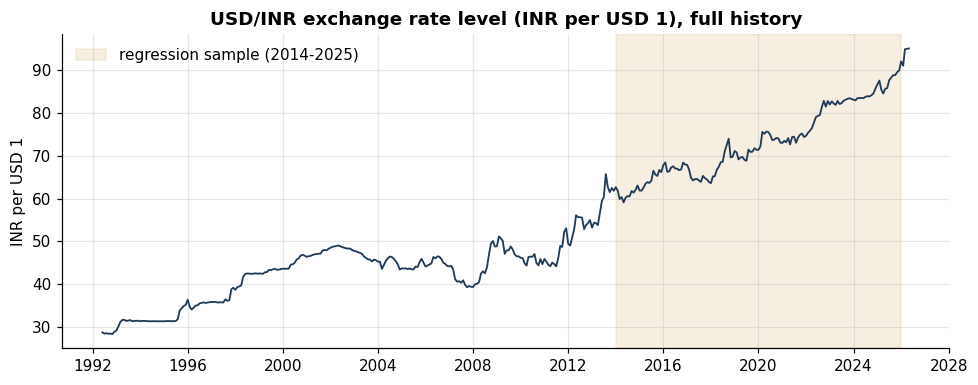

In [12]:
# Figure 1 — USD/INR level (full history)
lv = pd.read_csv(io.StringIO(USDINR_FULL_CSV), index_col=0); lv.index = pd.PeriodIndex(lv.index, freq="M")
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(lv.index.to_timestamp(), lv["USDINR"].values, color=NAVY, lw=1.2)
ax.axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-12-31"), color=GOLD, alpha=0.15, label="regression sample (2014-2025)")
ax.set_title("USD/INR exchange rate level (INR per USD 1), full history", fontweight="bold")
ax.set_ylabel("INR per USD 1"); ax.legend(loc="upper left", frameon=False)
fig.tight_layout(); fig.savefig("charts/fig1_usdinr_level.png", dpi=120, bbox_inches="tight"); plt.show()

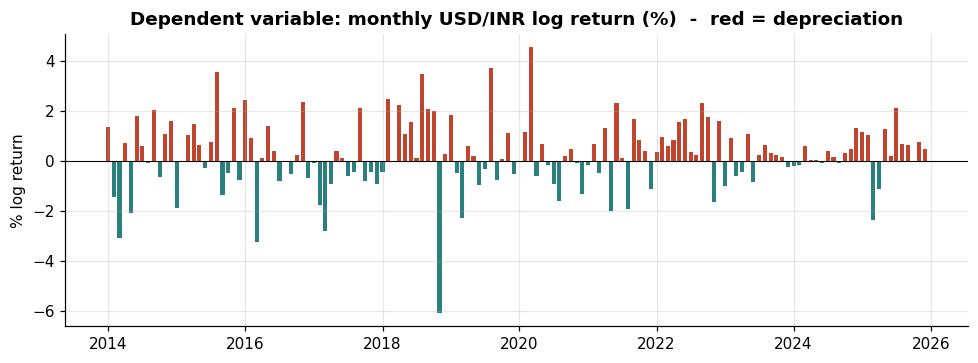

In [13]:
# Figure 2 — dependent variable
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(t, y.values, width=22, color=[RUST if v > 0 else TEAL for v in y.values]); ax.axhline(0, color="k", lw=0.7)
ax.set_title("Dependent variable: monthly USD/INR log return (%)  -  red = depreciation", fontweight="bold")
ax.set_ylabel("% log return")
fig.tight_layout(); fig.savefig("charts/fig2_dependent_return.png", dpi=120, bbox_inches="tight"); plt.show()

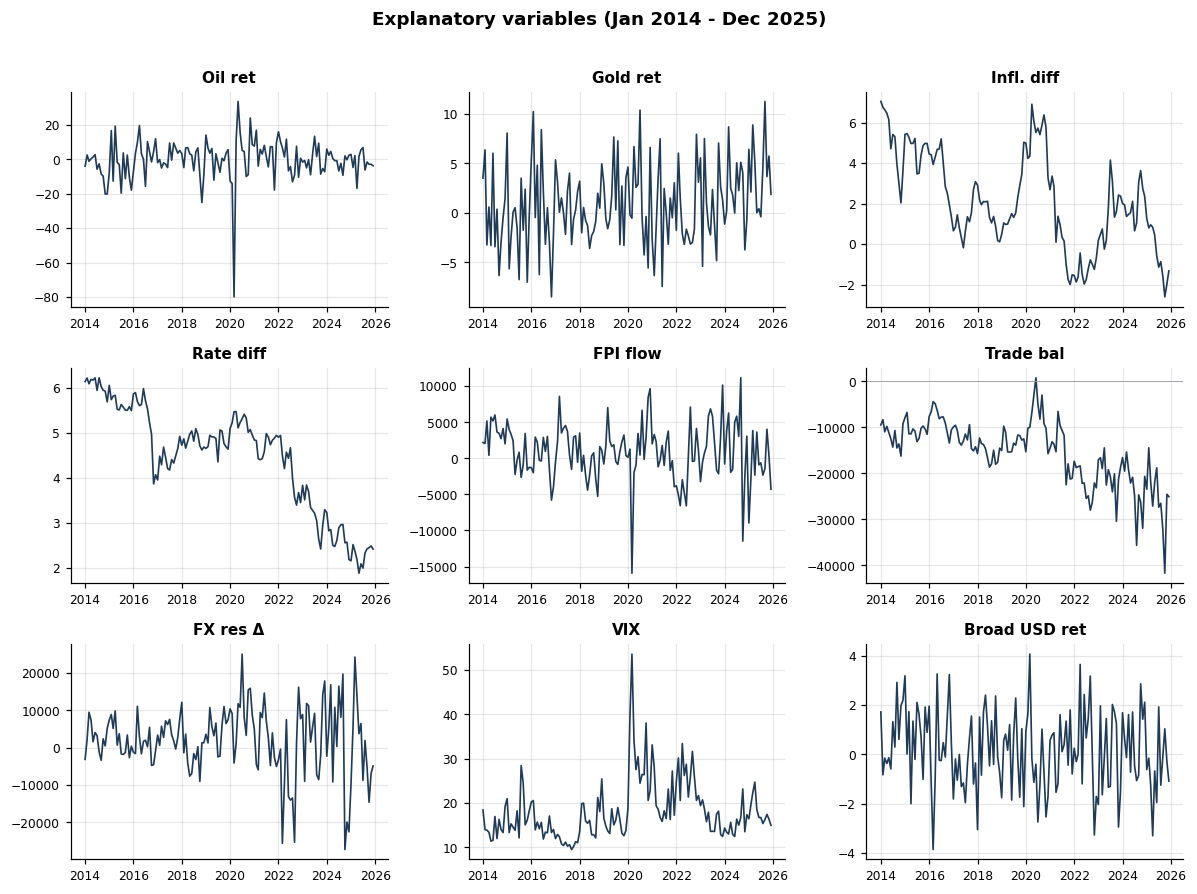

In [14]:
# Figure 3 — explanatory variables over time
fig, axes = plt.subplots(3, 3, figsize=(11, 8)); axes = axes.ravel()
for i, c in enumerate(REG):
    axes[i].plot(t, data[c].values, color=NAVY, lw=1.1)
    axes[i].set_title(LAB[c], fontsize=10, fontweight="bold"); axes[i].tick_params(labelsize=8)
    if c == "Trade_Balance": axes[i].axhline(0, color=GREY, lw=0.6)
fig.suptitle("Explanatory variables (Jan 2014 - Dec 2025)", fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig("charts/fig3_drivers_timeseries.png", dpi=120, bbox_inches="tight"); plt.show()

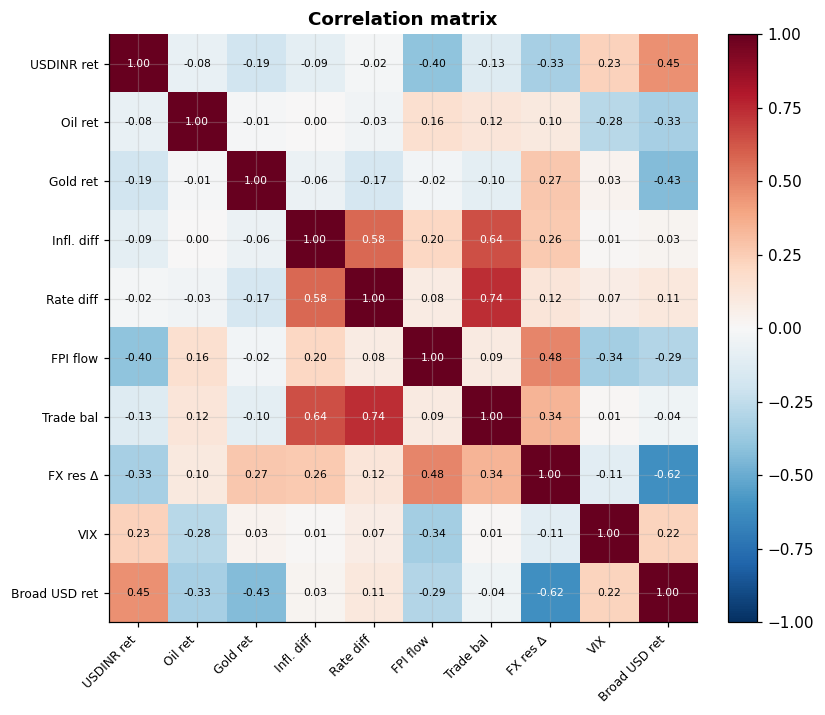

In [15]:
# Figure 4 — correlation heatmap
corr = data.corr(); fig, ax = plt.subplots(figsize=(8, 6.6)); im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels([LAB[c] for c in corr.columns], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([LAB[c] for c in corr.columns], fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.values[i,j]) > 0.55 else "black")
ax.set_title("Correlation matrix", fontweight="bold"); fig.colorbar(im, fraction=0.046, pad=0.04)
fig.tight_layout(); fig.savefig("charts/fig4_corr_heatmap.png", dpi=120, bbox_inches="tight"); plt.show()

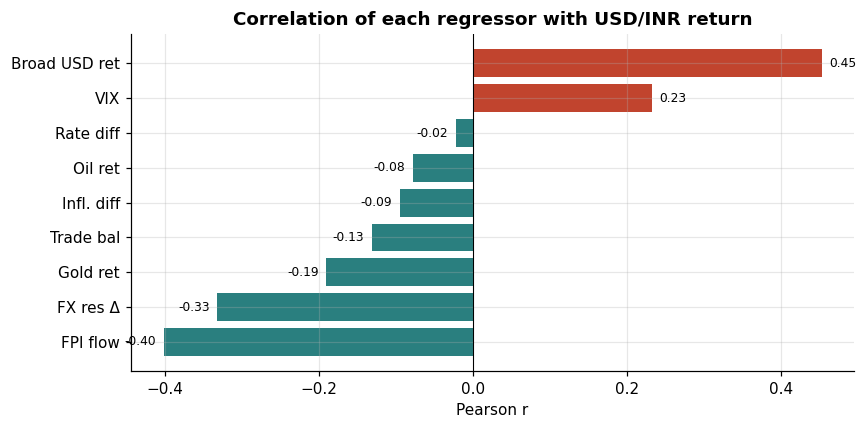

In [16]:
# Figure 5 — correlation with the dependent variable
cd = corr[DEP].drop(DEP).sort_values(); fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([LAB[c] for c in cd.index], cd.values, color=[RUST if v > 0 else TEAL for v in cd.values]); ax.axvline(0, color="k", lw=0.7)
ax.set_title("Correlation of each regressor with USD/INR return", fontweight="bold"); ax.set_xlabel("Pearson r")
for i, v in enumerate(cd.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
fig.tight_layout(); fig.savefig("charts/fig5_corr_with_dep_bar.png", dpi=120, bbox_inches="tight"); plt.show()

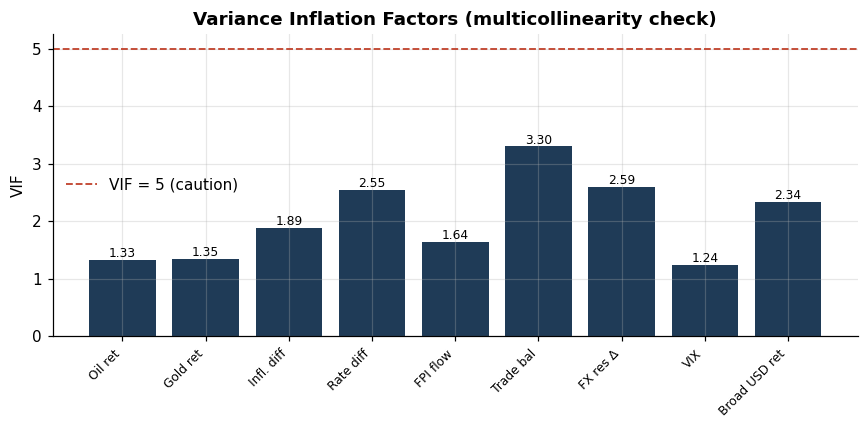

In [17]:
# Figure 6 — Variance Inflation Factors
fig, ax = plt.subplots(figsize=(8, 4)); ax.bar([LAB[c] for c in vif["variable"]], vif["VIF"], color=NAVY)
ax.axhline(5, color=RUST, ls="--", lw=1.2, label="VIF = 5 (caution)")
ax.set_title("Variance Inflation Factors (multicollinearity check)", fontweight="bold"); ax.set_ylabel("VIF")
ax.legend(frameon=False); plt.xticks(rotation=45, ha="right", fontsize=8)
for i, v in enumerate(vif["VIF"]): ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=8)
fig.tight_layout(); fig.savefig("charts/fig6_vif_bar.png", dpi=120, bbox_inches="tight"); plt.show()

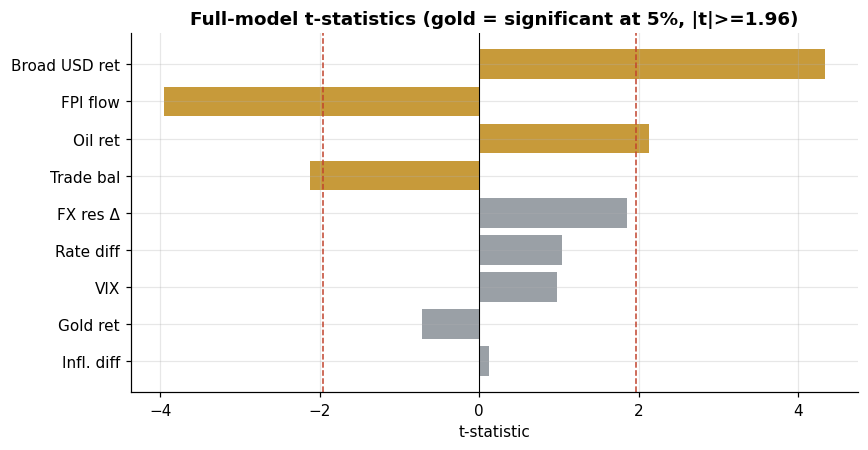

In [18]:
# Figure 7 — full-model t-statistics
tv = full.tvalues.drop("const"); order = tv.abs().sort_values().index; fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh([LAB[c] for c in order], [tv[c] for c in order], color=[GOLD if abs(tv[c]) >= 1.96 else GREY for c in order])
ax.axvline(1.96, color=RUST, ls="--", lw=1); ax.axvline(-1.96, color=RUST, ls="--", lw=1); ax.axvline(0, color="k", lw=0.7)
ax.set_title("Full-model t-statistics (gold = significant at 5%, |t|>=1.96)", fontweight="bold"); ax.set_xlabel("t-statistic")
fig.tight_layout(); fig.savefig("charts/fig7_full_tstats_bar.png", dpi=120, bbox_inches="tight"); plt.show()

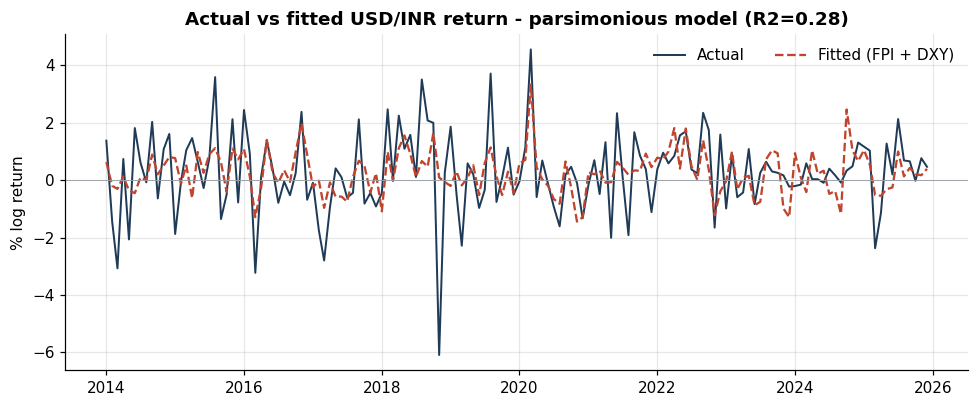

In [19]:
# Figure 8 — actual vs fitted
fig, ax = plt.subplots(figsize=(9, 3.8)); ax.plot(t, y.values, color=NAVY, lw=1.3, label="Actual")
ax.plot(t, red.fittedvalues.values, color=RUST, lw=1.5, ls="--", label="Fitted (FPI + DXY)"); ax.axhline(0, color=GREY, lw=0.6)
ax.set_title(f"Actual vs fitted USD/INR return - parsimonious model (R2={red.rsquared:.2f})", fontweight="bold")
ax.set_ylabel("% log return"); ax.legend(frameon=False, ncol=2)
fig.tight_layout(); fig.savefig("charts/fig8_actual_vs_fitted.png", dpi=120, bbox_inches="tight"); plt.show()

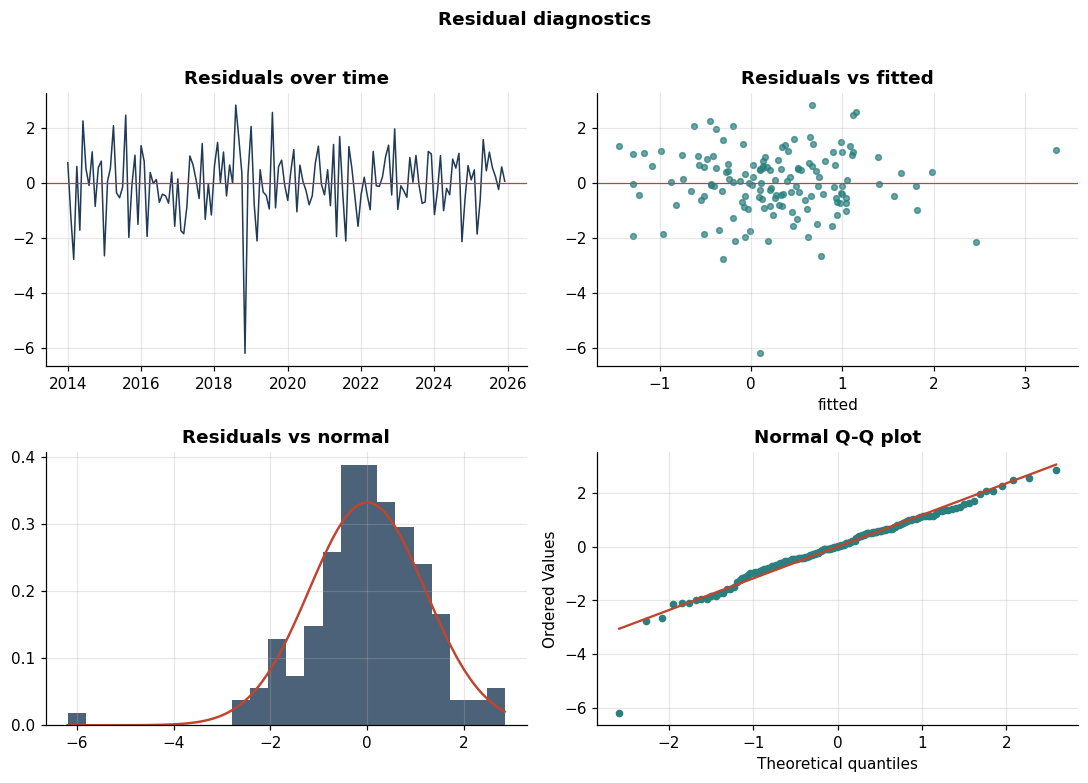

In [20]:
# Figure 9 — residual diagnostics
res = red.resid; fitv = red.fittedvalues; fig = plt.figure(figsize=(10, 7)); gs = GridSpec(2, 2, figure=fig)
a1 = fig.add_subplot(gs[0, 0]); a1.plot(t, res.values, color=NAVY, lw=1); a1.axhline(0, color=RUST, lw=0.8); a1.set_title("Residuals over time", fontweight="bold")
a2 = fig.add_subplot(gs[0, 1]); a2.scatter(fitv.values, res.values, s=14, color=TEAL, alpha=0.7); a2.axhline(0, color=RUST, lw=0.8); a2.set_title("Residuals vs fitted", fontweight="bold"); a2.set_xlabel("fitted")
a3 = fig.add_subplot(gs[1, 0]); a3.hist(res.values, bins=24, color=NAVY, alpha=0.8, density=True)
xs = np.linspace(res.min(), res.max(), 100); a3.plot(xs, stats.norm.pdf(xs, res.mean(), res.std()), color=RUST, lw=1.6); a3.set_title("Residuals vs normal", fontweight="bold")
a4 = fig.add_subplot(gs[1, 1]); stats.probplot(res.values, dist="norm", plot=a4)
a4.get_lines()[0].set_color(TEAL); a4.get_lines()[0].set_markersize(4); a4.get_lines()[1].set_color(RUST); a4.set_title("Normal Q-Q plot", fontweight="bold")
fig.suptitle("Residual diagnostics", fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig("charts/fig9_residual_diagnostics.png", dpi=120, bbox_inches="tight"); plt.show()

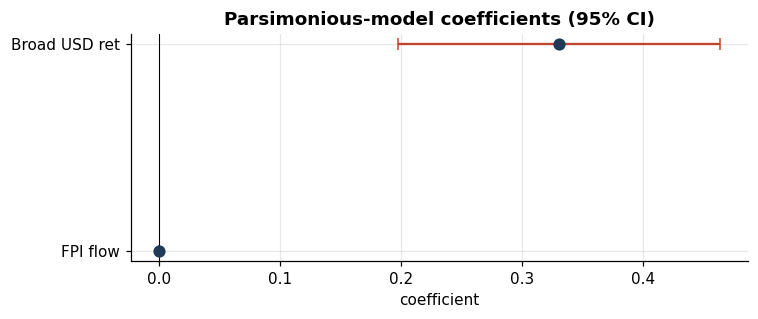

In [21]:
# Figure 10 — parsimonious-model coefficients (95% CI)
ci = red.conf_int(); params = red.params.drop("const"); fig, ax = plt.subplots(figsize=(7, 3)); yp = range(len(params))
ax.errorbar(params.values, list(yp), xerr=[(params - ci[0].drop("const")).values, (ci[1].drop("const") - params).values],
            fmt="o", color=NAVY, ecolor=RUST, capsize=4, ms=7); ax.axvline(0, color="k", lw=0.7)
ax.set_yticks(list(yp)); ax.set_yticklabels([LAB[c] for c in params.index])
ax.set_title("Parsimonious-model coefficients (95% CI)", fontweight="bold"); ax.set_xlabel("coefficient")
fig.tight_layout(); fig.savefig("charts/fig10_reduced_coef_ci.png", dpi=120, bbox_inches="tight"); plt.show()

In [22]:
# Final model
print("USDINR_Return = "
      f"{red.params['const']:.3f} + " + " + ".join(f"{red.params[c]:.6g}*{c}" for c in FINAL))

USDINR_Return = 0.299 + -0.000106499*FPI_Flow + 0.330459*Broad_USD_Return


## 12. Conclusion

**Preferred model (preferred specification):**

`USDINR_Return  =  0.299  −  0.000106 · FPI_Flow  +  0.331 · Broad_USD_Return`

- **Broad dollar strength is the strongest same-month correlate.** A 1 pp rise in the broad dollar index return is associated with ~0.33 pp rupee depreciation (p < 0.001; largest standardized beta ~0.47).
- **Net foreign inflows co-move with a stronger rupee.** Each +US$1 bn net FPI inflow is associated with ~0.11% appreciation (p < 0.001).
- **Macro fundamentals show no reliable monthly association** — inflation/rate differentials and the trade balance are non-stationary *and* insignificant; this echoes Meese-Rogoff.
- **Full-model signals are mixed**, which is *why* parsimony matters: `Oil_Return` is significant under classical SE but not under HAC; `FX_Reserves_Change` is significant only under HAC; `Trade_Balance` is significant but non-stationary in levels. After combining stationarity, robustness, parsimony and model selection, FPI flows and broad USD strength are the variables **retained in the preferred specification** — not a claim that they are the only ones that matter.
- **Model quality:** R^2 ~0.28 (modest, as expected for monthly FX); passes serial-correlation, heteroskedasticity and functional-form checks; residuals non-normal; conclusions robust to HAC standard errors.
- **Caveats:** results are **contemporaneous associations, not causal or out-of-sample forecasts** (FPI and the rupee are jointly determined); residuals are fat-tailed; `Broad_USD_Return` (FRED `DTWEXBGS`) is a public proxy for the ICE DXY. Natural extensions: lagged regressors, explicit crisis dummies, and the GPR index as a VIX alternative.